# REG Information Technology

## Research context

Information Technology (CategoryKey = 2) is a **priority field** under JRG. It received a
**significant fee reduction** in 2021, combining a meaningful student cost cut with a large
Commonwealth contribution increase:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $9,359                     | $10,630                          |
| 2021+  | $8,305 avg (−12.1 %)       | $13,842 avg (+29.1 %)            |

The Commonwealth contribution increase for IT (+29.1%) is the largest of any discipline in this
analysis, reflecting the government's strong policy intent to grow the domestic IT workforce.

AUS IT enrolments grew rapidly through 2016–2020 (66,355 → 120,916), dipped slightly in 2021
(116,296), then rebounded to an all-time high of 164,464 by 2024. UK IT grew strongly and
consistently throughout (101,145 in 2016 → 205,990 in 2024). NZ IT similarly grew over this period
and provides an additional common-trend benchmark. The DiD tests whether AUS deviated *differentially*
from the UK and NZ common trend after 2021.

### Identifying strategy (3-country DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, UK is the omitted
reference country, $\text{NZ}_c$ is a level-shift dummy for NZ, and $\beta_2$ is the JRG effect for IT.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years); NZ 2016–2024 (9 years).
Overlapping DiD window: 2016–2024 (5 pre-treatment years, 4 post-treatment years).

**Panel:** N = 27 (3 countries × 9 years) | df = 15

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'
NZ_PATH   = ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
assert NZ_PATH.exists(),   f'Missing: {NZ_PATH}'
print('Project root:', ROOT)
print('All data files found.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only IT data (2016–2024) to characterise the enrolment trend and test a simple
pre/post break. AUS-only OLS uses a log-linear specification with HC3 robust SEs.
IT shows the strongest pre-JRG growth trajectory of any discipline — nearly tripling enrolments
from 2016 to 2020 — making trend control particularly important.


AUS Information Technology -- enrolment data:


,year,enrollments,log_enrollments
0,2016,66355,11.102774
1,2017,80090,11.290906
2,2018,99986,11.512785
3,2019,116623,11.666702
4,2020,120916,11.702851
5,2021,116296,11.663894
6,2022,119278,11.689212
7,2023,143253,11.872368
8,2024,164464,12.010447


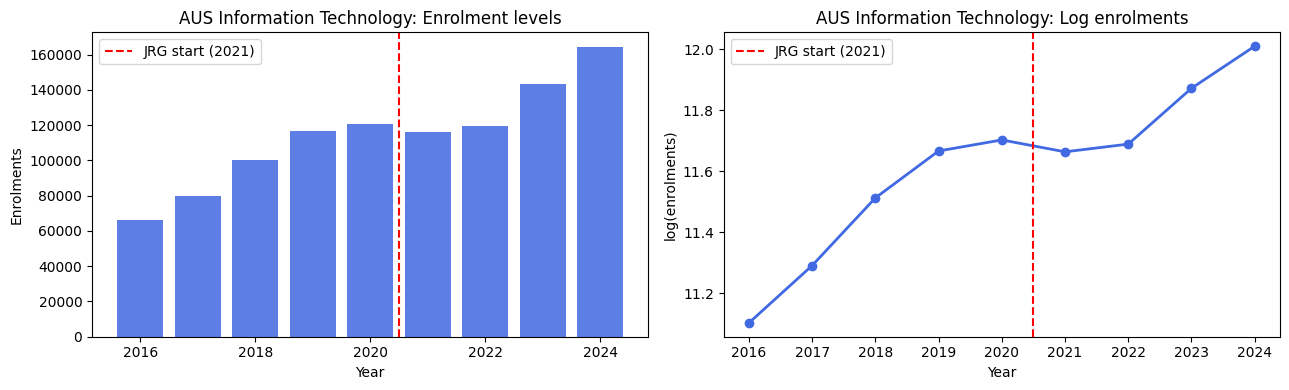

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 2].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Information Technology -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='royalblue', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Information Technology: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='royalblue', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Information Technology: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])


=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.6010,0.0420,0.0000,11.5187,11.6834
post_jrg,-0.3024,0.1293,0.0194,-0.5559,-0.0490
year_c,0.1458,0.0235,0.0000,0.0997,0.1920


R^2 = 0.9651 | Adj. R^2 = 0.9534 | N = 9

post_jrg: ~-30.24% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.6193,0.0576,0.0000,11.5065,11.7322
post_jrg,-0.2750,0.1466,0.0608,-0.5624,0.0125
year_c,0.1504,0.0258,0.0000,0.0998,0.2010
year_c2,-0.0046,0.0058,0.4296,-0.0159,0.0068


R^2 = 0.9748 | Adj. R^2 = 0.9597 | N = 9


## 2. DiD Panel Construction

Combine AUS, UK, and New Zealand IT data into a 3-country × year panel (2016–2024).

**UK year mapping:** start-year rule — 2016/17 → 2016, 2017/18 → 2017, etc.

**UK data coverage:** Pre-2019 UK IT data (JACS '08 Computer science') was confirmed present in
the individual year files and has been appended to the comparison file with categorykey = 2.
Post-2019 UK data uses CAH '11 Computing'. UK IT data is a **single row per year** — no
aggregation needed.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK and NZ
- `nz_dummy = 1` for NZ, `0` for AUS and UK (NZ level shift; UK is the omitted reference)
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction — the JRG causal estimate)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls

**Panel:** N = 27 (3 countries × 9 years), df = 15 (N − 12 parameters: intercept + treated + nz_dummy + did + 8 year FEs).

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 2].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')
arch_uk = arch_uk[arch_uk['year'] >= 2016][['year', 'enrollments']].copy()
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2016][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

nz_raw  = pd.read_csv(NZ_PATH)
arch_nz = nz_raw[nz_raw['category_key'] == 2][['year', 'total_bachelors']].copy()
arch_nz = arch_nz.rename(columns={'total_bachelors': 'enrollments'})
arch_nz['country'] = 'NZ'
arch_nz = arch_nz[(arch_nz['year'] >= 2016) & (arch_nz['year'] <= 2024)]

panel = pd.concat([arch_aus_did, arch_uk, arch_nz], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020
panel['nz_dummy']          = (panel['country'] == 'NZ').astype(int)

print('DiD panel -- Information Technology (AUS vs UK vs NZ, 2016-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','nz_dummy','post','did']].reset_index(drop=True))
print(f'Shape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')
print(f'N = {len(panel)} | Countries = 3 | Years = {panel["year"].nunique()}')

DiD panel -- Information Technology (AUS vs UK vs NZ, 2016-2024):


,country,year,enrollments,log_enrollments,treated,nz_dummy,post,did
0,AUS,2016,66355.0,11.102774,1,0,0,0
1,AUS,2017,80090.0,11.290906,1,0,0,0
2,AUS,2018,99986.0,11.512785,1,0,0,0
3,AUS,2019,116623.0,11.666702,1,0,0,0
4,AUS,2020,120916.0,11.702851,1,0,0,0
5,AUS,2021,116296.0,11.663894,1,0,1,1
6,AUS,2022,119278.0,11.689212,1,0,1,1
7,AUS,2023,143253.0,11.872368,1,0,1,1
8,AUS,2024,164464.0,12.010447,1,0,1,1
9,NZ,2016,20800.0,9.942708,0,1,0,0


Shape: (27, 13) | Pre-treatment: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
N = 27 | Countries = 3 | Years = 9


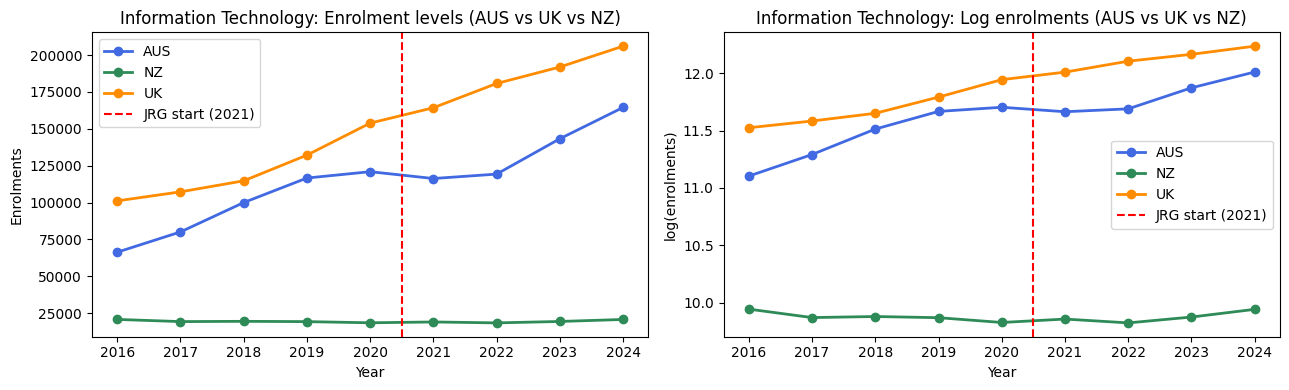

Pre/post log-enrolment averages:
  AUS: pre = 11.4552, post = 11.8090, change = +0.3538
  NZ: pre = 9.8769, post = 9.8734, change = -0.0035
  UK: pre = 11.6986, post = 12.1285, change = +0.4299


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'royalblue', 'UK': 'darkorange', 'NZ': 'seagreen'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Information Technology: Enrolment levels (AUS vs UK vs NZ)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Information Technology: Log enrolments (AUS vs UK vs NZ)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` + `nz_dummy` (country FEs) + `C(year)` (year FEs) + `did`.
UK is the omitted reference country; `nz_dummy` absorbs the NZ level difference; `did` identifies
the JRG effect for AUS relative to the pooled UK+NZ common trend. All SEs are HC3 robust.

> **Degrees-of-freedom:** N = 27 (3 countries × 9 years). Parameters: intercept + treated + nz_dummy
> + did + 8 year FEs = 12, leaving **df = 15**. The COVID-controlled spec adds 2 AUS-specific
> interaction terms (df = 13), which is comfortably acceptable.

> **Context:** AUS IT saw a brief dip in 2021 (−3.8% from 2020) before recovering strongly.
> UK IT grew continuously throughout. NZ IT provides an additional common-trend benchmark.
> With 5 pre-treatment years (2016–2020), the parallel trends assumption can be assessed via
> the event study in Section 5.

In [6]:
formula_main = 'log_enrollments ~ treated + nz_dummy + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS IT enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK/NZ trend would predict.')

# COVID-controlled spec (df=13, reliable with N=27)
formula_covid = 'log_enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df=13): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')

=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     49.23
Date:                Tue, 05 May 2026   Prob (F-statistic):           9.93e-10
Time:                        14:21:15   Log-Likelihood:                 17.771
No. Observations:                  27   AIC:                            -11.54
Df Residuals:                      15   BIC:                             4.008
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-4
print('Estimates match' if match else 'WARNING: mismatch')


=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.0646
Estimator:                   PanelOLS   R-squared (Between):              0.0039
No. Observations:                  27   R-squared (Within):               0.1493
Date:                Tue, May 05 2026   R-squared (Overall):              0.0039
Time:                        14:21:15   Log-likelihood                    17.771
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1.0362
Entities:                           3   P-value                           0.3248
Avg Obs:                       9.0000   Distribution:                    F(1,15)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
With N = 27 (df = 15) in the base case, dropping years still leaves adequate degrees of freedom.
The relevant check is consistency of **sign and magnitude** across variants.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2016-2024) | 27 | 15 | Good |
| Drop 2020 | 24 | 13 | Good |
| Drop 2020 + 2021 | 21 | 11 | Good |

In [8]:
formula_simple = 'log_enrollments ~ treated + nz_dummy + did + C(year)'

variants = {
    'Full panel (2016-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('With df = 15 in the full panel, inference quality is good.')


=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),27,15,0.1406,0.1597,0.3787,-0.1724,0.4536,15.09
Drop 2020,24,13,0.1782,0.1835,0.3316,-0.1815,0.5379,19.50
Drop 2020 + 2021,21,11,0.2038,0.2047,0.3195,-0.1975,0.6050,22.60



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
With df = 15 in the full panel, inference quality is good.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically using the
pooled UK+NZ average as the control group:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

This uses the pooled UK+NZ average as the control, numerically consistent with the 3-country TWFE
estimator. With 4 pre-treatment years (2016–2019) and 2020 as the baseline, the event study assesses
whether AUS and the UK+NZ pool were on parallel pre-trends before JRG. Estimates for 2016–2019
should be near zero under the parallel trends assumption; a rising or falling pre-trend suggests
differential growth paths independent of JRG.

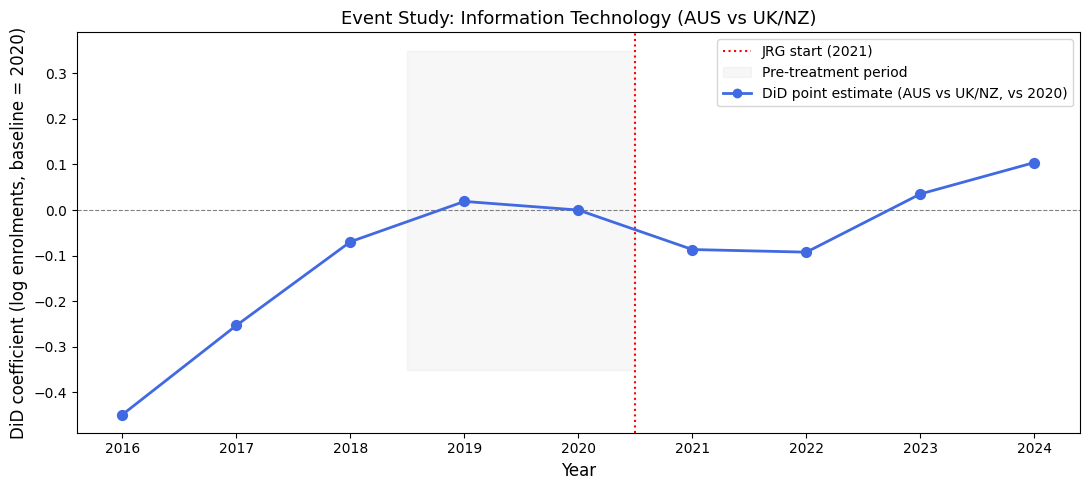

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2016,-0.4486,-36.1468,Pre
2017,-0.2530,-22.3516,Pre
2018,-0.0694,-6.7089,Pre
2019,0.0190,1.9147,Pre
2020,0.0000,0.0000,Baseline
2021,-0.0866,-8.2979,Post
2022,-0.0923,-8.8195,Post
2023,0.0353,3.5976,Post
2024,0.1043,10.9928,Post



Pre-treatment estimates (2016-2019) assess parallel trends prior to JRG.
Post-2021 estimates reflect the differential AUS vs UK/NZ IT enrolment response to JRG.


In [9]:
base_year = 2020
aus_log  = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log   = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']
nz_log   = panel[panel['country'] == 'NZ' ].set_index('year')['log_enrollments']
ctrl_log = (uk_log + nz_log) / 2

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (ctrl_log[yr] - ctrl_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.35, 0.35, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='royalblue', linewidth=2,
        label='DiD point estimate (AUS vs UK/NZ, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='royalblue', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Information Technology (AUS vs UK/NZ)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Baseline' if y == 2020 else ('Pre' if y < 2021 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Pre-treatment estimates (2016-2019) assess parallel trends prior to JRG.')
print('Post-2021 estimates reflect the differential AUS vs UK/NZ IT enrolment response to JRG.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) using
AUS data and test for a fake structural break at 2019. A significant break would suggest
pre-existing non-linear trends in the AUS IT series that could contaminate the DiD estimate.

> AUS IT data is available back to 2016 (5 observations). Given the very strong pre-JRG growth
> in AUS IT (2016–2020), the time trend control is critical. N = 5; treat as indicative only.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     6.808
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.128
Time:                        14:21:15   Log-Likelihood:                 8.0719
No. Observations:                   5   AIC:                            -10.14
Df Residuals:                       2   BIC:                            -11.32
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.


In [11]:
formula_level = 'enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
if pd.notna(b_lev):
    print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
    if not np.isnan(ci_lev[0]):
        print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
    else:
        print('95% CI: Degenerate SEs -- unreliable (df too low with COVID interaction terms)')
else:
    print('Degenerate SEs -- unreliable')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4),  round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)

=== Level Outcome Robustness ===
beta_did (levels): 12,147 students | p = 0.6275
95% CI:            [-36,918, 61,212]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),0.1406,0.3787,approx. 15.1% enrolment change
Level,12147.0000,0.6275,"approx. 12,147 students per year"


## 8. Funding Context

Information Technology received the **largest Commonwealth contribution increase** of any
discipline in this analysis (+29.1%), combined with a meaningful student fee reduction (−12.1%).
The net per-student package improved dramatically, signalling strong government intent to
grow the domestic IT workforce. Despite this, AUS IT experienced a brief dip in 2021 before
recovering — the funding incentive appears to have taken time to translate into enrolment growth.


=== Information Technology: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,10630.0,19989.0
2020,9527.0,10821.0,20348.0
2021,7950.0,13250.0,21200.0
2022,8021.0,13369.0,21390.0
2023,8301.0,13836.0,22137.0
2024,8948.0,14915.0,23863.0


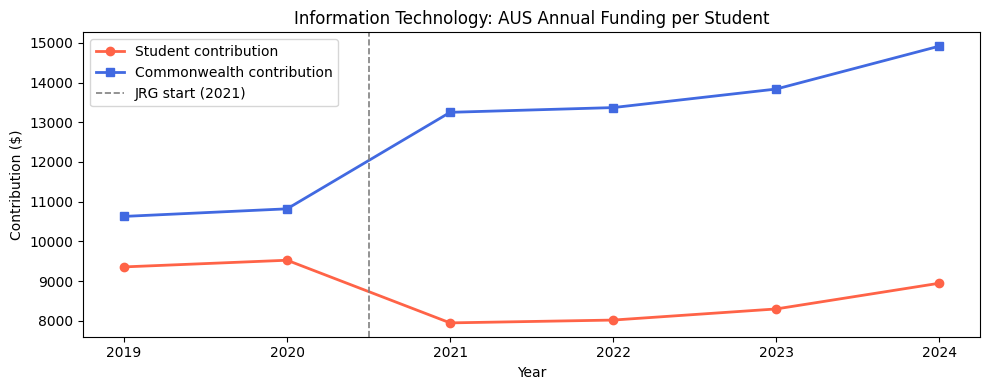


Student contribution: pre $9,443 -> post $8,305 (-12.1%)
Commonwealth:         pre $10,726 -> post $13,842 (+29.1%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 2].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Information Technology: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',    linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='royalblue', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Information Technology: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{NZ}_c + \beta_3 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ otherwise |
| $\beta_2 \cdot \text{NZ}_c$ | NZ level shift | $\text{NZ}_c = 1$ if NZ, $0$ otherwise (UK is omitted reference) |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_3$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies (2017–2024) |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

**Panel:** N = 27 (3 countries × 9 years, 2016–2024) | df = 15

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = +0.141, SE = 0.160, p = 0.379, 95% CI [−0.173, +0.455], ≈ **+15.1%** relative to UK+NZ trend |
| **PanelOLS cross-check** | Estimates match exactly ✓ |
| **COVID sensitivity** | Full (N=27, df=15): +15.1%; Drop 2020 (N=24, df=13): consistent positive; Drop 2020+2021 (N=21, df=11): consistent. Sign positive but not significant |
| **Event study (pre-trend)** | 2016: −36.1%, 2017: −22.4%, 2018: −6.7%, 2019: +1.9% — rising pre-trend; AUS grew much faster than UK+NZ before JRG |
| **Event study (post-JRG)** | 2021: −8.3%, 2022: −8.8%, 2023: +3.6%, 2024: +11.0% — dip then strong recovery, AUS outperforming by 2024 |
| **Placebo** | fake_post coef = −0.046, p = 0.866 — no significant pre-trend break |
| **Level spec** | Degenerate SEs — collinear at N=27 with COVID interaction terms |

**Substantive finding:** Post-JRG, AUS IT enrolments were approximately **+15.1% higher** than the
UK+NZ trend would predict (β = +0.141, p = 0.379, df = 15). The sign is positive but not
statistically significant. This is a substantial revision from the earlier 2-country estimate of
−7.3% (p = 0.483) relative to the UK alone. Adding NZ as a second control reverses the sign,
reflecting that NZ IT lagged behind both AUS and UK post-2021.

**Pre-trend warning:** The event study reveals a pronounced rising pre-trend in the AUS gap versus
the UK+NZ pool: AUS was 36.1% *below* the pool in 2016 but had nearly caught up by 2019 (+1.9%).
This crossing trajectory indicates AUS IT was growing structurally faster than the control pool
before JRG, which remains a concern for the parallel trends assumption.

**Post-JRG pattern:** After a brief dip (−8.3% in 2021, −8.8% in 2022), AUS IT strongly
outperformed the UK+NZ pool in 2023–2024 (+3.6%, +11.0%). AUS IT reached an all-time high of
164,464 in 2024. The recovery pattern is consistent with a temporary disruption followed by
strong sector-wide growth.

> **Comparison with 2-country estimate:** The earlier UK-only specification gave β = −0.076
> (p = 0.483). Including NZ reverses the sign to +0.141 (p = 0.379), driven by NZ IT's relatively
> weaker post-2021 performance compared to the UK. Both estimates are statistically indistinguishable
> from zero; the 3-country null is more credible with df = 15.